# Reinforcement Learning for State Separation


## Setup


In [1]:
%pip install matplotlib

import json
import math 
import numpy as np
import os
import pandas as pd
from pprint import pprint
from matplotlib import pyplot as plt
from statistics import mean, median, stdev
from typing import List 

You should consider upgrading via the '/Users/christophstein/Documents/jku/qcs-rl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
plt.rcParams["figure.dpi"] = 120

In [3]:
LOG_DIR = "logs"
TARGET_DIR = "tmp/figs"

In [4]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

## Data Loading Functions


In [5]:
def load_json(path: str):
    with open(path, "r") as config_file:
        return json.load(config_file)

In [6]:
def show_only_n_labels(ax, n: int = 10) -> None:
    show_every_kth = math.ceil(len(ax.xaxis.get_ticklabels()) / n)

    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if i % show_every_kth != 0:
            label.set_visible(False)

In [7]:
def load_monitor_data(path: str, n_eval_episodes: int, eval_frequency: int) -> pd.DataFrame:
    monitor_df_raw = pd.read_csv(path, skiprows=1)

    assert len(monitor_df_raw) % n_eval_episodes == 0

    per_eval_data = []
    for i in range(int(len(monitor_df_raw) / n_eval_episodes)):

        start_step = i * n_eval_episodes
        end_step = start_step + n_eval_episodes

        current_eval_df = monitor_df_raw[start_step: end_step + 1]

        r_mean = current_eval_df["r"].mean()
        r_stdev = current_eval_df["r"].std()

        # only compute length scores for successful rounds
        # cutoff value is based on reward function.
        current_eval_succ_df = current_eval_df[current_eval_df["r"] > 0]
        
        l_mean = current_eval_succ_df["l"].mean()
        l_stdev = current_eval_succ_df["l"].std()

        succ_pct = len(current_eval_succ_df) / len(current_eval_df)

        train_step = (i + 1) * eval_frequency
        train_step = f"{round(train_step / 10**6, 2)} Mio."

        per_eval_data.append({
            "steps": train_step,
            "r_mean": r_mean,
            "r_stdev": r_stdev,
            "r_lower_bound": r_mean - r_stdev,
            "r_upper_bound": r_mean + r_stdev,
            "l_mean": l_mean,
            "l_stdev": l_stdev,
            "l_lower_bound": l_mean - l_stdev,
            "l_upper_bound": l_mean + l_stdev,
            "succ_pct": succ_pct,
        })

    return pd.DataFrame(per_eval_data)

In [8]:
def merge_seed_dfs(seed_dfs: List[pd.DataFrame]) -> pd.DataFrame:
    # assert same lengths
    assert len(set([len(df) for df in seed_dfs])
               ) == 1, "All seed runs need to have the same amount of steps!"

    merged_data = []

    for i in range(len(seed_dfs[0])):

        steps = []
        r_seed_means = []
        l_seed_means = []
        succ_pct_seed_means = []

        for seed_df in seed_dfs:
            row = seed_df.iloc[[i]]
            steps.append(row["steps"].values[0])
            r_seed_means.append(row["r_mean"].values[0])
            l_seed_means.append(row["l_mean"].values[0])
            succ_pct_seed_means.append(row["succ_pct"].values[0])

        assert len(set(steps)) == 1, "Steps mismatch between seed runs!"

        r_mean = mean(r_seed_means)
        r_stdev = stdev(r_seed_means)
        l_mean = mean(l_seed_means)
        l_stdev = stdev(l_seed_means)
        succ_pct_mean = mean(succ_pct_seed_means)
        succ_pct_stdev = stdev(succ_pct_seed_means)

        merged_data.append({
            "steps": steps[0],
            "r_mean": r_mean,
            "r_stdev": r_stdev,
            "r_lower_bound": r_mean - r_stdev,
            "r_upper_bound": r_mean + r_stdev,
            "l_mean": l_mean,
            "l_stdev": l_stdev,
            "l_lower_bound": l_mean - l_stdev,
            "l_upper_bound": l_mean + l_stdev,
            "succ_pct_mean": succ_pct_mean,
            "succ_pct_stdev": succ_pct_stdev,
            "succ_pct_lower_bound": succ_pct_mean - succ_pct_stdev,
            "succ_pct_upper_bound": succ_pct_mean + succ_pct_stdev,
        })

    return pd.DataFrame(merged_data)

## Data Analysis Functions


In [9]:
def plot_rewards(dfs: List[pd.DataFrame], labels: List[str], plot_stdev: bool = True, target_path: str = None):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["r_mean"], label=label)

        if plot_stdev:
            ax.fill_between(
                df["steps"], df["r_lower_bound"], df["r_upper_bound"], alpha=0.3
            )

    ax.set_xlabel("steps")
    ax.set_ylabel("reward")

    if len(dfs) > 1:
        plt.legend()

    show_only_n_labels(ax, n=15)

    plt.grid()
    plt.xticks(fontsize=9, rotation=45)

    if target_path is not None:
        plt.savefig(target_path)

    plt.show()

In [10]:
def plot_circuit_lengths(dfs: List[pd.DataFrame], labels: List[str], plot_stdev: bool = True, target_path: str = None):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["l_mean"], label=label)

        if plot_stdev:
            ax.fill_between(
                df["steps"], df["l_lower_bound"], df["l_upper_bound"], alpha=0.3
            )

    ax.set_xlabel("steps")
    ax.set_ylabel("circuit length of successfull runs")

    if len(dfs) > 1:
        plt.legend()

    show_only_n_labels(ax, n=15)

    plt.grid()
    plt.xticks(fontsize=9, rotation=45)

    if target_path is not None:
        plt.savefig(target_path)


    plt.show()

In [11]:
def plot_succ_pct_per_seed(dfs: List[pd.DataFrame], labels: List[str], target_path: str = None):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["succ_pct"], label=label)

    ax.set_xlabel("steps")
    ax.set_ylabel("success percentage")

    if len(dfs) > 1:
        plt.legend()

    show_only_n_labels(ax, n=15)

    plt.grid()
    plt.xticks(fontsize=9, rotation=45)

    if target_path is not None:
        plt.savefig(target_path)


    plt.show()

In [12]:
def plot_succ_pct_per_experiment(dfs: List[pd.DataFrame], labels: List[str], plot_stdev: bool = True, target_path: str = None):
    ax = plt.subplot()

    for df, label in zip(dfs, labels):
        ax.plot(df["steps"], df["succ_pct_mean"], label=label)

        if plot_stdev:
            ax.fill_between(
                df["steps"], df["succ_pct_lower_bound"], df["succ_pct_upper_bound"], alpha=0.3
            )

    ax.set_xlabel("steps")
    ax.set_ylabel("success percentage")

    if len(dfs) > 1:
        plt.legend()

    show_only_n_labels(ax, n=15)

    plt.grid()
    plt.xticks(fontsize=9, rotation=45)

    if target_path is not None:
        plt.savefig(target_path)


    plt.show()

## Main


In [13]:
experiment_dir_paths = [
    res.path for res in os.scandir(LOG_DIR) if res.is_dir()]
experiment_dir_paths.sort()

experiments_by_qubit = {}
experiments_by_gate_count = {}

for experiment_dir_path in experiment_dir_paths:
    experiment_config_name = experiment_dir_path.split("/")[-1]


    experiment_seed_dir_paths = [res.path for res in os.scandir(
        experiment_dir_path) if res.is_dir()]

    experiment_seed_configs = [
        load_json(f"{dir_path}/config.json") for dir_path in experiment_seed_dir_paths
    ]

    experiment_seed_dfs = []
    for config, path in zip(experiment_seed_configs, experiment_seed_dir_paths):

        # TODO: config param naming glattziehen
        df = load_monitor_data(f"{path}/test.monitor.csv",
                               n_eval_episodes=config["eval_params"]["n_eval_episodes"],
                               eval_frequency=config["eval_params"]["eval_freq"]
                               )
        experiment_seed_dfs.append(df)


    # Uncomment if you want per-seed results

    # printb(f"\n{experiment_config_name}:")
    # pprint(experiment_seed_configs[0])

    # seed_labels = [
    #     f"seed_{config['common_params']['seed']}" for config in experiment_seed_configs
    # ]
    
    # print("\nPer seed results:")
    # target_path_prefix = f"{TARGET_DIR}/experiment_{config['common_params']['qubit_num']}q_{config['common_params']['gate_count']}g"
    # plot_rewards(experiment_seed_dfs, seed_labels, plot_stdev=False, target_path=f"{target_path_prefix}_rewards_per_seed.png")
    # plot_succ_pct_per_seed(experiment_seed_dfs, seed_labels, target_path=f"{target_path_prefix}_succ_pct_per_seed.png")
    # plot_circuit_lengths(experiment_seed_dfs, seed_labels, plot_stdev=False, target_path=f"{target_path_prefix}_circuit_lengths_per_seed.png")


    experiment_df = merge_seed_dfs(experiment_seed_dfs)

    qubit_num = str(config["common_params"]["qubit_num"])
    gate_count = str(config["common_params"]["gate_count"])

    if config["common_params"]["curriculum_learning"]:
        label = f"curriculum learning"
    else:
        label = f"{gate_count} gates"

    if qubit_num in experiments_by_qubit:
        experiments_by_qubit[qubit_num][label] = experiment_df
    else:
        experiments_by_qubit[qubit_num] = {label: experiment_df}

    if label in experiments_by_gate_count:
        experiments_by_gate_count[label][qubit_num] = experiment_df
    else:
        experiments_by_gate_count[label] = {qubit_num: experiment_df}


Experiment runs for circuits with 10 gates:


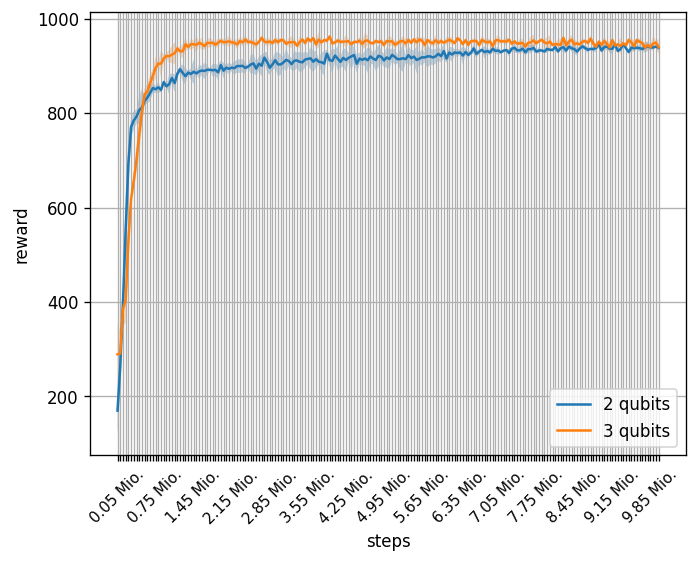

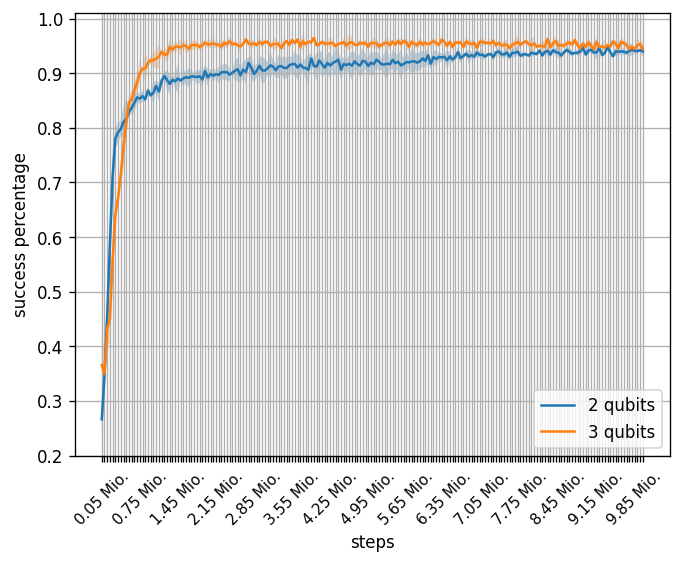

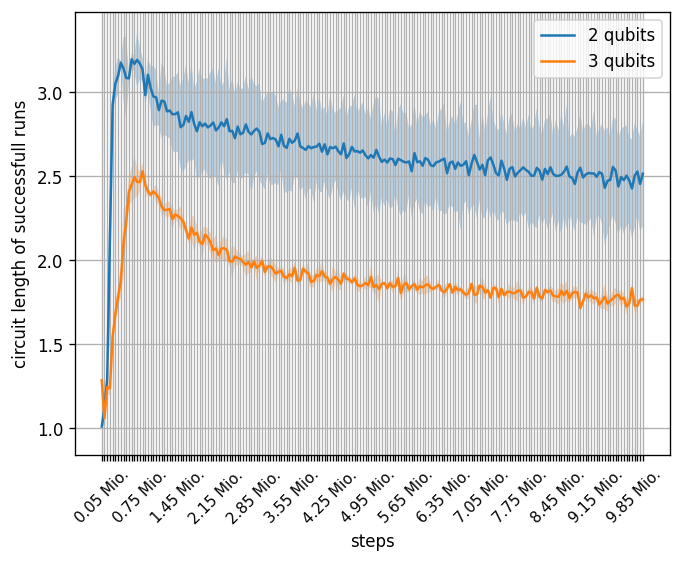


Experiment runs for circuits with 15 gates:


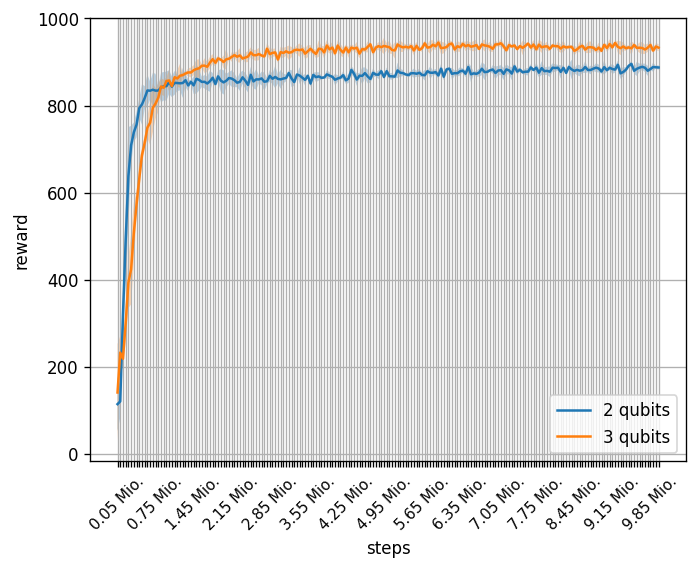

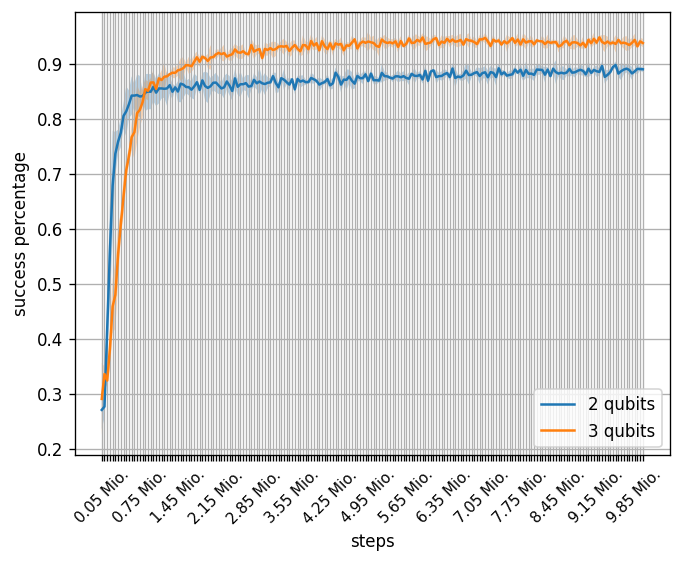

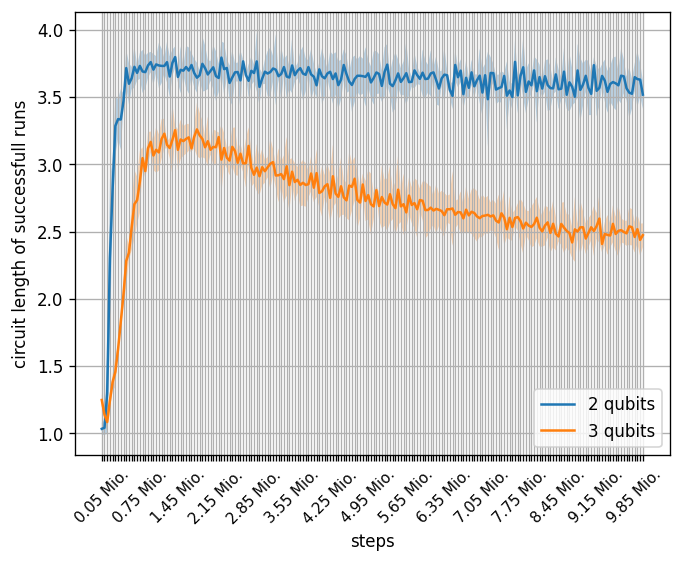


Experiment runs for circuits with 20 gates:


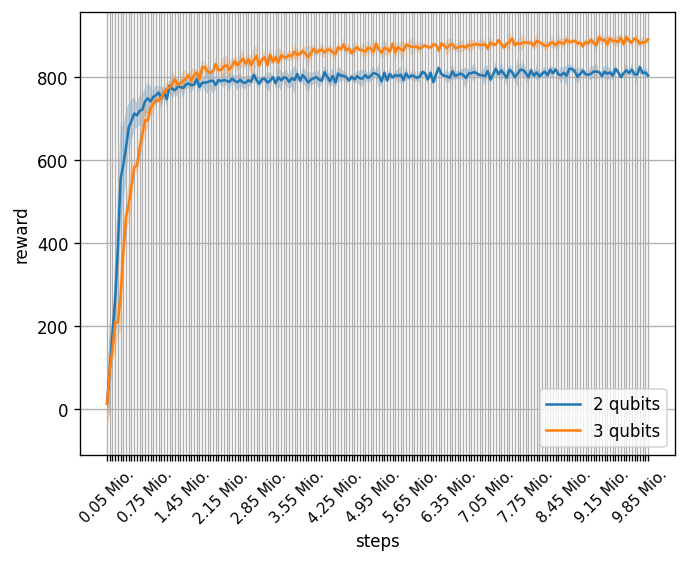

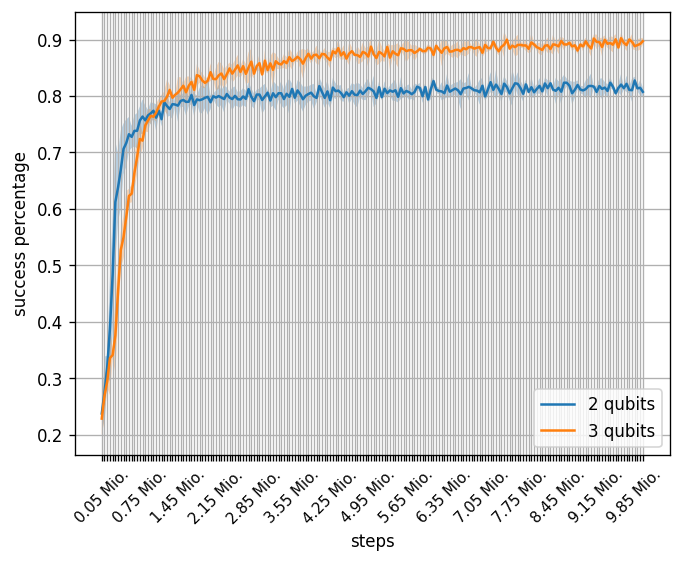

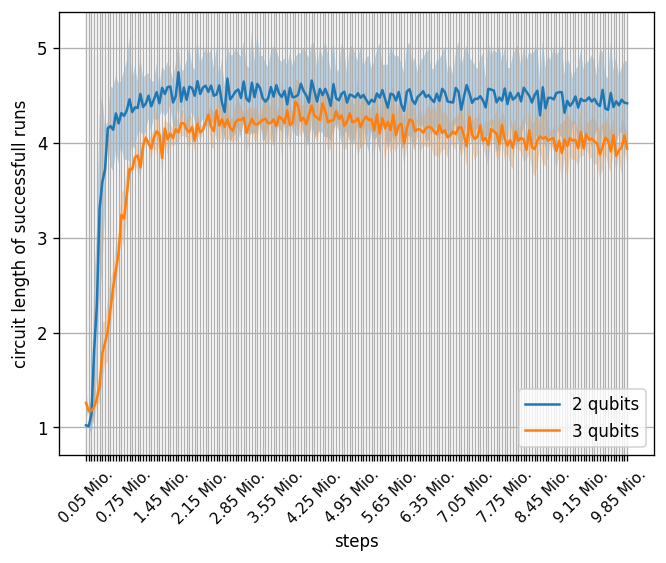


Experiment runs for circuits with 25 gates:


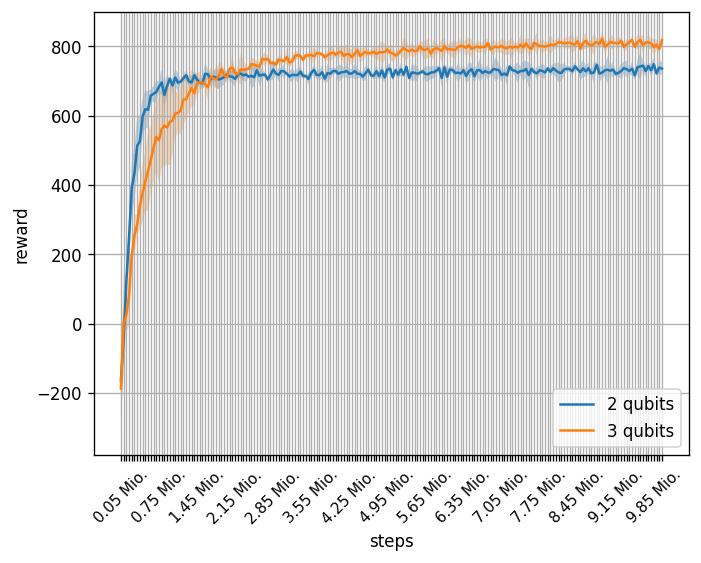

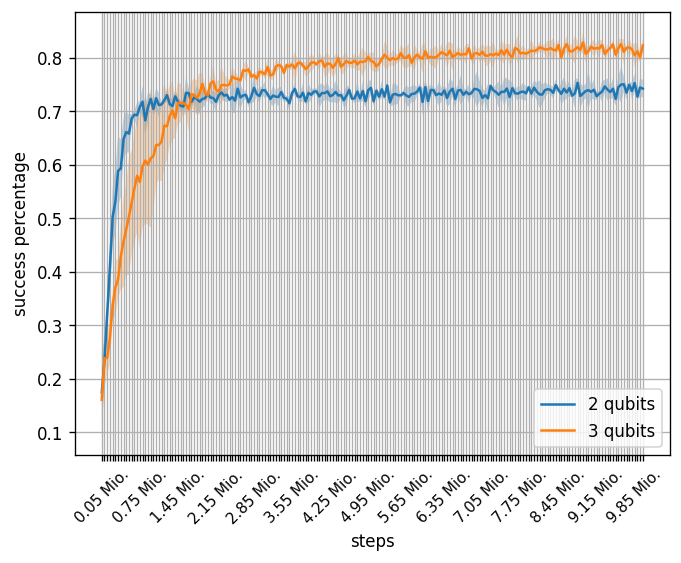

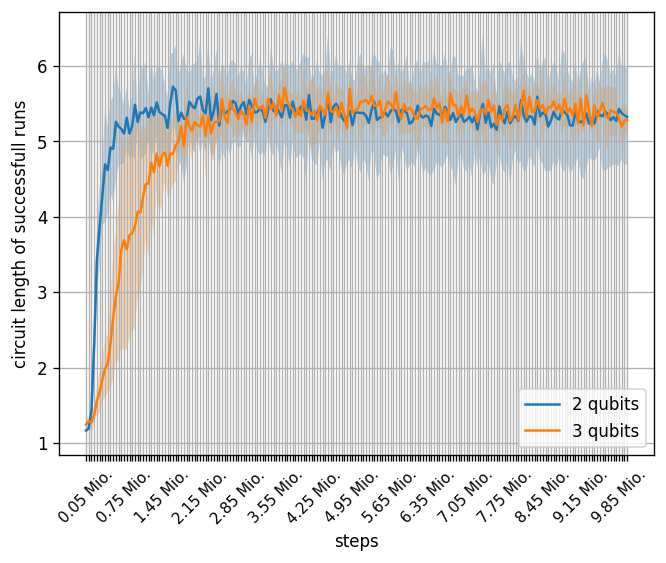


Experiment runs for circuits with curriculum learning:


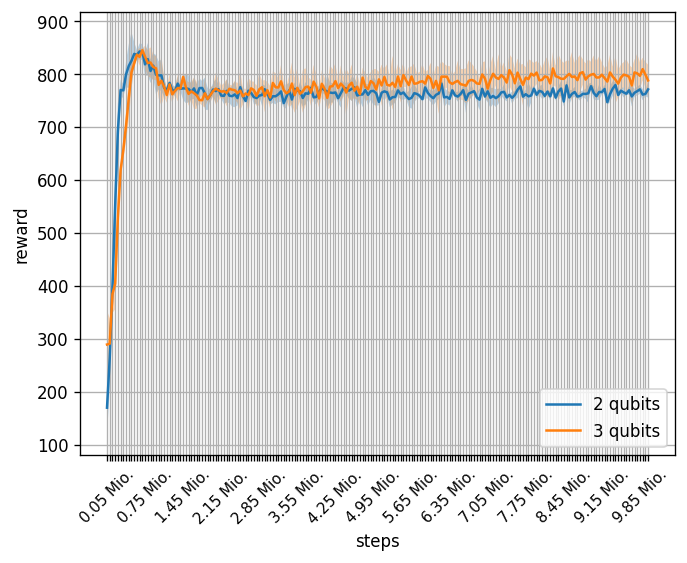

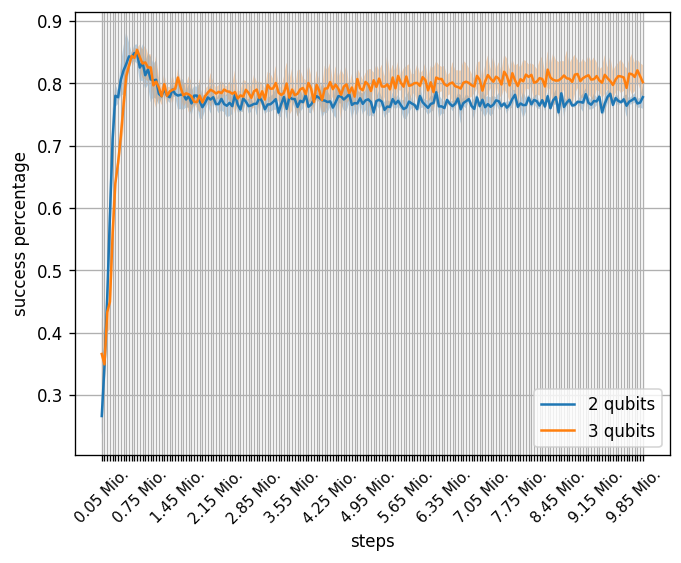

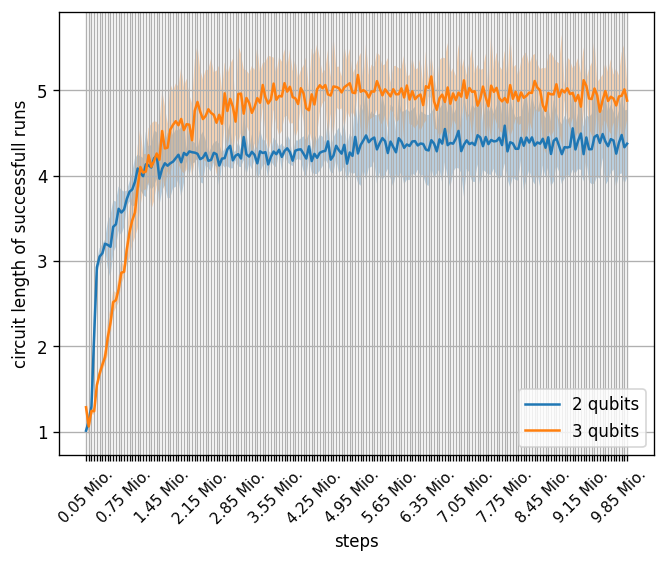

In [14]:
gate_count_labels = [str(key) for key in experiments_by_gate_count.keys()]
gate_count_labels.sort()

for gate_count_label in gate_count_labels:
    
    experiment_dfs = []
    labels = []

    for qubit_num in experiments_by_gate_count[gate_count_label]:
        experiment_dfs.append(experiments_by_gate_count[gate_count_label][qubit_num])
        labels.append(f"{qubit_num} qubits")

    print()
    
    printb(f"Experiment runs for circuits with {gate_count_label}:")
    target_path_prefix = f"{TARGET_DIR}/experiment_{gate_count_label}g"
    plot_rewards(experiment_dfs, labels=labels, plot_stdev=True, target_path=f"{target_path_prefix}_rewards.png")
    plot_succ_pct_per_experiment(experiment_dfs, labels=labels, plot_stdev=True, target_path=f"{target_path_prefix}_succ_pct.png")
    plot_circuit_lengths(experiment_dfs, labels=labels, plot_stdev=True, target_path=f"{target_path_prefix}_circuit_lengths.png")


Experiment runs for 2 qubits:


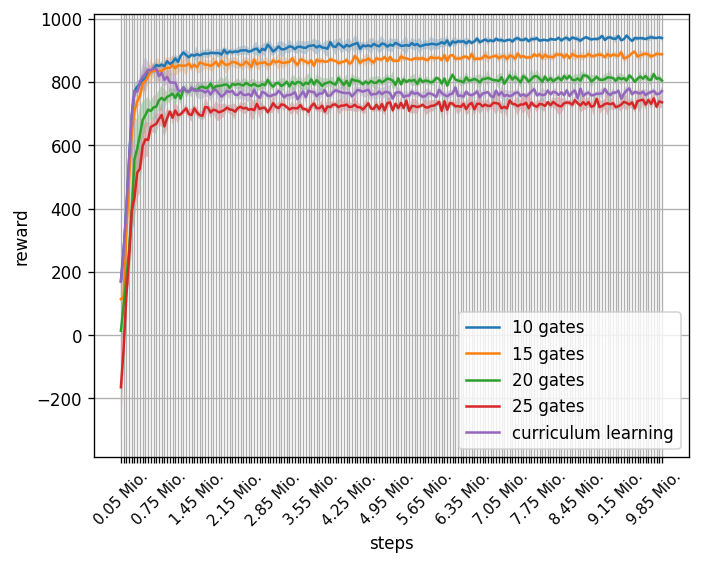

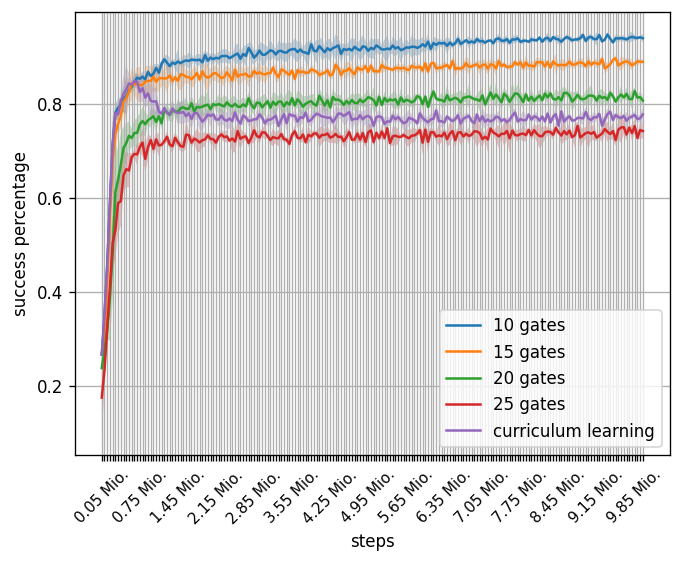

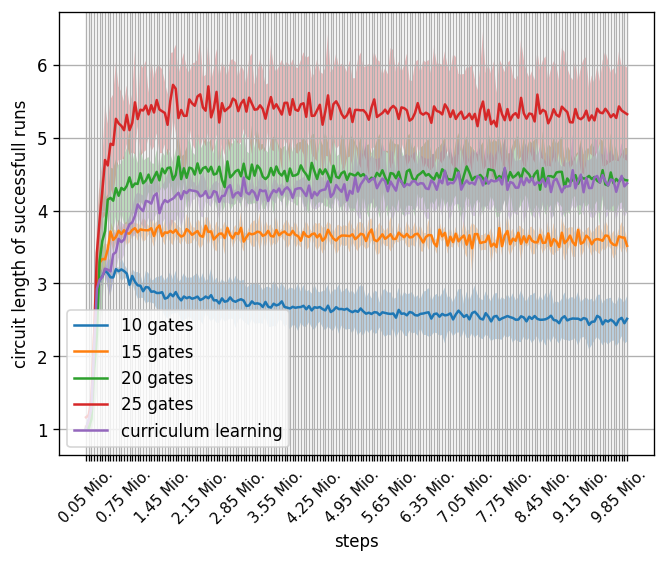


Experiment runs for 3 qubits:


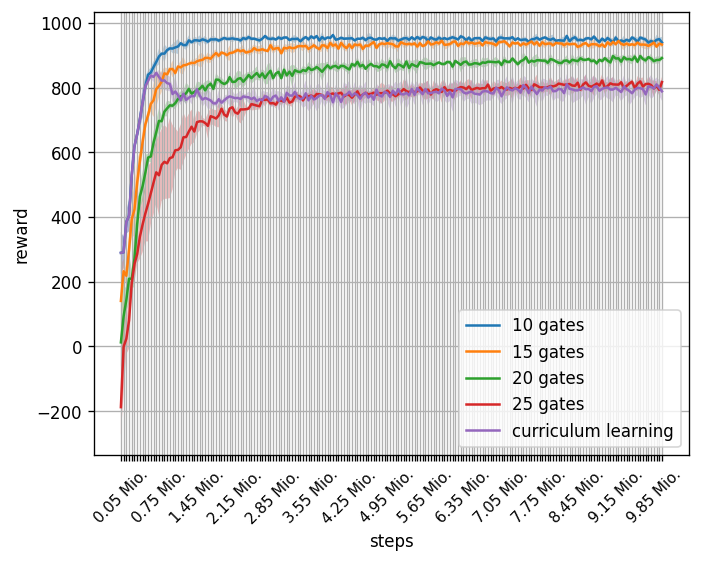

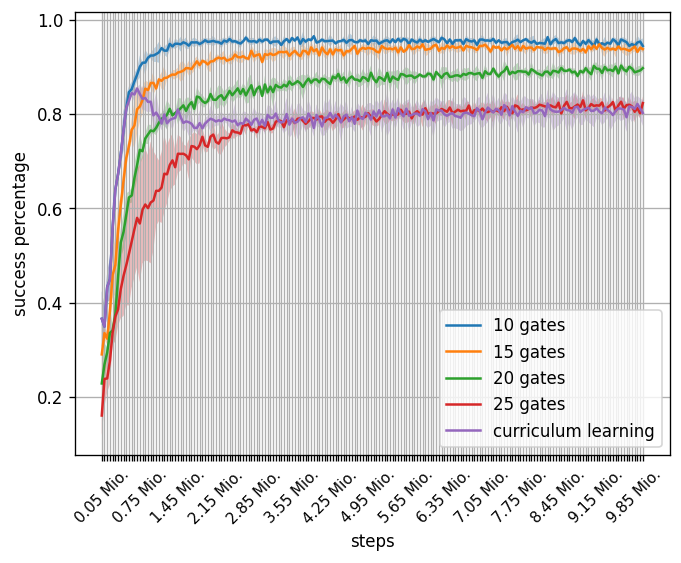

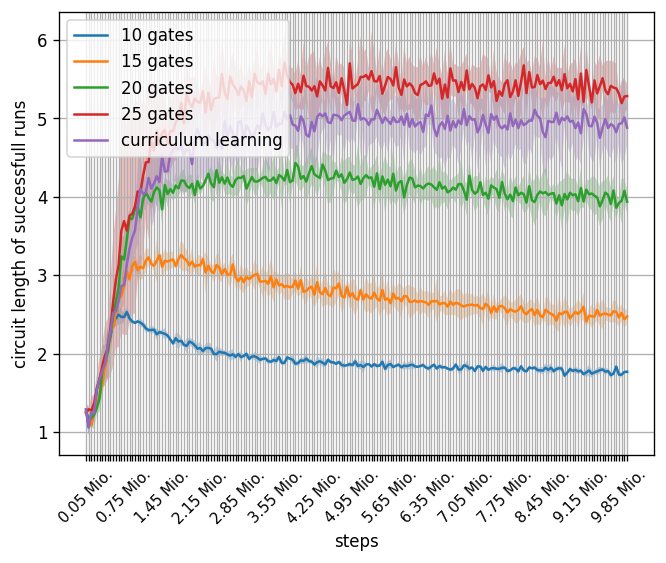

In [15]:
qubit_nums = [str(key) for key in experiments_by_qubit.keys()]
qubit_nums.sort()

for qubit_num in qubit_nums:
    
    experiment_dfs = []
    labels = []

    gate_count_labels = [str(key) for key in experiments_by_qubit[qubit_num].keys()]
    gate_count_labels.sort()

    for gate_count_label in gate_count_labels:
        experiment_dfs.append(experiments_by_qubit[qubit_num][gate_count_label])
        labels.append(f"{gate_count_label}")

    print()
    
    printb(f"Experiment runs for {qubit_num} qubits:")
    target_path_prefix = f"{TARGET_DIR}/experiment_{qubit_num}q"
    plot_rewards(experiment_dfs, labels=labels, plot_stdev=True, target_path=f"{target_path_prefix}_rewards.png")
    plot_succ_pct_per_experiment(experiment_dfs, labels=labels, plot_stdev=True, target_path=f"{target_path_prefix}_succ_pct.png")
    plot_circuit_lengths(experiment_dfs, labels=labels, plot_stdev=True, target_path=f"{target_path_prefix}_circuit_lengths.png")